<a href="https://colab.research.google.com/github/pavi020/customer-segmentation-ml/blob/main/customer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Customer Segmentation



A machine learning project that uses K-Means Clustering and Principal Component Analysis (PCA) to segment customers into distinct groups based on demographic and spending behavior, enabling better customer understanding and targeted marketing strategies.

In [37]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder,StandardScaler,MinMaxScaler
from sklearn.cluster import KMeans,MeanShift, DBSCAN, estimate_bandwidth
from sklearn.mixture import GaussianMixture
from  sklearn.decomposition import PCA
from sklearn.metrics import calinski_harabasz_score,davies_bouldin_score,silhouette_score

This cell imports all the necessary libraries for data manipulation, visualization, preprocessing, clustering, and evaluation. It includes `pandas` for dataframes, `numpy` for numerical operations, `seaborn` and `matplotlib.pyplot` for plotting, `sklearn.preprocessing` for data scaling and encoding, `sklearn.cluster` for clustering algorithms, `sklearn.mixture` for Gaussian Mixture Models, `sklearn.decomposition` for PCA, and `sklearn.metrics` for evaluating clustering performance.

###Loading and Cleaning the Dataset

In [39]:
import zipfile
import os

zip_file_path = '/content/Online Retail.xlsx.zip'
extracted_dir = '/content/'
excel_file_name = 'Online Retail.xlsx' # Assuming the Excel file inside is named 'Online Retail.xlsx'
extracted_excel_path = os.path.join(extracted_dir, excel_file_name)

# Extract the Excel file from the zip archive
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    # Assuming 'Online Retail.xlsx' is directly inside the zip
    zip_ref.extract(excel_file_name, extracted_dir)

original_df = pd.DataFrame(pd.read_excel(extracted_excel_path))
original_df.dropna(inplace = True)
original_df.reset_index(inplace = True,drop = True)
original_df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
406824,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
406825,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
406826,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
406827,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


This cell handles the loading of the dataset. It first defines the path to a zipped Excel file. It then extracts the `Online Retail.xlsx` file from the zip archive. Finally, it reads the Excel file into a pandas DataFrame named `original_df`, drops any rows with missing values, resets the DataFrame index, and displays the first few rows of the cleaned DataFrame.

In [40]:
initial_df  = original_df.copy()

This cell creates a copy of the `original_df` and assigns it to `initial_df`. This is a good practice to preserve the original dataset while performing transformations on a copy.

In [41]:
initial_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 406829 entries, 0 to 406828
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    406829 non-null  object        
 1   StockCode    406829 non-null  object        
 2   Description  406829 non-null  object        
 3   Quantity     406829 non-null  int64         
 4   InvoiceDate  406829 non-null  datetime64[ns]
 5   UnitPrice    406829 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      406829 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 24.8+ MB


This cell displays a concise summary of the `initial_df` DataFrame using the `.info()` method. It provides information about the DataFrame's index dtype, column dtypes, non-null values, and memory usage.

###Encoding Categorical Features

In [15]:
le = LabelEncoder()

categories = ['InvoiceNo','StockCode','Description','InvoiceDate','CustomerID','Country']

for category in categories:

        initial_df[category] = le.fit_transform(initial_df[category].astype(str))


initial_df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,0,3249,3716,6,0,2.55,4048,35
1,0,2649,3724,6,0,3.39,4048,35
2,0,2855,861,8,0,2.75,4048,35
3,0,2803,1813,6,0,3.39,4048,35
4,0,2802,2776,6,0,3.39,4048,35
...,...,...,...,...,...,...,...,...
406824,18535,1470,2263,12,20459,0.85,275,13
406825,18535,1746,695,6,20459,2.10,275,13
406826,18535,2086,701,4,20459,4.15,275,13
406827,18535,2087,700,4,20459,4.15,275,13


This cell performs label encoding on specified categorical features in the `initial_df`. It initializes a `LabelEncoder` and then iterates through the `categories` list (`InvoiceNo`, `StockCode`, `Description`, `InvoiceDate`, `CustomerID`, `Country`). For each category, it converts the column to string type (to handle potential mixed types after dropping NaNs earlier) and then applies `fit_transform` to convert categorical labels into numerical values. Finally, it displays the transformed DataFrame.

In [16]:
initial_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 406829 entries, 0 to 406828
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    406829 non-null  int64  
 1   StockCode    406829 non-null  int64  
 2   Description  406829 non-null  int64  
 3   Quantity     406829 non-null  int64  
 4   InvoiceDate  406829 non-null  int64  
 5   UnitPrice    406829 non-null  float64
 6   CustomerID   406829 non-null  int64  
 7   Country      406829 non-null  int64  
dtypes: float64(1), int64(7)
memory usage: 24.8 MB


This cell again uses the `.info()` method to display the DataFrame's summary after the label encoding. This helps verify that the specified columns have been converted to numerical (integer) types.

In [17]:
initial_df.describe()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
count,406829.000000,406829.000000,406829.000000,406829.000000,406829.000000,406829.000000,406829.000000,406829.000000
mean,9950.901755,1573.257501,2024.692726,12.061303,10895.552697,3.460471,2176.377102,32.827731
std,5552.295845,844.054584,1089.177346,248.693370,5975.017014,69.315162,1255.543861,6.738565
min,0.000000,0.000000,0.000000,-80995.000000,0.000000,0.000000,0.000000,0.000000
25%,5060.000000,937.000000,1143.000000,2.000000,5635.000000,1.250000,1196.000000,35.000000
50%,10310.000000,1522.000000,1987.000000,5.000000,11447.000000,1.950000,2073.000000,35.000000
75%,14651.000000,2106.000000,2945.000000,12.000000,16148.000000,3.750000,3287.000000,35.000000
max,22189.000000,3683.000000,3895.000000,80995.000000,20459.000000,38970.000000,4371.000000,36.000000


This cell generates descriptive statistics for all numerical columns in the `initial_df` using the `.describe()` method. It provides insights into the central tendency, dispersion, and shape of each column's distribution, including count, mean, standard deviation, min, max, and quartile values.

###Data Cleaning and Preprocessing

In [18]:
initial_df.drop(axis=1,columns='InvoiceDate',inplace=True)
wrong_data = initial_df[initial_df['Quantity']<0].index
wrong_data
initial_df.drop(index=wrong_data,axis=0,inplace=True)
initial_df.reset_index(drop=True,inplace=True)
initial_df

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID,Country
0,0,3249,3716,6,2.55,4048,35
1,0,2649,3724,6,3.39,4048,35
2,0,2855,861,8,2.75,4048,35
3,0,2803,1813,6,3.39,4048,35
4,0,2802,2776,6,3.39,4048,35
...,...,...,...,...,...,...,...
397919,18535,1470,2263,12,0.85,275,13
397920,18535,1746,695,6,2.10,275,13
397921,18535,2086,701,4,4.15,275,13
397922,18535,2087,700,4,4.15,275,13


This cell performs further data cleaning and preprocessing steps. It first drops the `InvoiceDate` column as it was encoded previously and might not be directly useful in its current encoded numerical form for clustering. It then identifies and removes rows where the 'Quantity' is negative (indicating returned items or errors). Finally, it resets the index of the DataFrame and displays the cleaned DataFrame.

In [19]:
initial_df.describe()


,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID,Country
count,397924.000000,397924.000000,397924.000000,397924.000000,397924.000000,397924.000000,397924.000000
mean,9716.398983,1570.578022,2024.882372,13.021823,3.116174,2181.236950,32.846476
std,5383.327369,842.859229,1089.516820,180.420210,22.096788,1255.222567,6.711504
min,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,4945.000000,936.000000,1143.000000,2.000000,1.250000,1206.000000,35.000000
50%,10123.000000,1521.000000,1987.000000,6.000000,1.950000,2079.000000,35.000000
75%,14414.000000,2106.000000,2947.000000,12.000000,3.750000,3291.000000,35.000000
max,18535.000000,3683.000000,3895.000000,80995.000000,8142.750000,4371.000000,36.000000


This cell again displays descriptive statistics for the `initial_df` after the data cleaning steps, specifically after removing rows with negative 'Quantity'. This allows for a quick check of the updated statistics and confirms the removal of invalid quantity entries.

###Normalizing the Data and Descriptive Statistics

In [20]:
scaler = MinMaxScaler(feature_range=(1,5))
normalized_array = scaler.fit_transform(initial_df)
normalized_df = pd.DataFrame(normalized_array,columns=initial_df.columns)
normalized_df

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID,Country
0,1.0,4.528645,4.816175,1.000247,1.001253,4.704415,4.888889
1,1.0,3.877002,4.824390,1.000247,1.001665,4.704415,4.888889
2,1.0,4.100733,1.884211,1.000346,1.001351,4.704415,4.888889
3,1.0,4.044257,2.861874,1.000247,1.001665,4.704415,4.888889
4,1.0,4.043171,3.850834,1.000247,1.001665,4.704415,4.888889
...,...,...,...,...,...,...,...
397919,5.0,2.596525,3.324005,1.000543,1.000418,1.251659,2.444444
397920,5.0,2.896280,1.713736,1.000247,1.001032,1.251659,2.444444
397921,5.0,3.265544,1.719897,1.000148,1.002039,1.251659,2.444444
397922,5.0,3.266630,1.718870,1.000148,1.002039,1.251659,2.444444


This cell normalizes the numerical data in the `initial_df` using `MinMaxScaler`. It scales the features to a specified range (1 to 5), which is useful for algorithms like K-Means that are sensitive to the scale of the data. The scaled data is stored in `normalized_array` and then converted back into a DataFrame named `normalized_df`, which is then displayed.

In [21]:
normalized_df.describe()

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID,Country
count,397924.000000,397924.000000,397924.000000,397924.000000,397924.000000,397924.000000,397924.000000
mean,3.096876,2.705759,3.079468,1.000594,1.001531,2.996099,4.649608
std,1.161765,0.915405,1.118888,0.008910,0.010855,1.148682,0.745723
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,2.067170,2.016563,2.173813,1.000049,1.000614,2.103638,4.888889
50%,3.184624,2.651914,3.040565,1.000247,1.000958,2.902539,4.888889
75%,4.110656,3.287266,4.026444,1.000543,1.001842,4.011668,4.888889
max,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


This cell displays descriptive statistics for the `normalized_df`. This helps to verify that the Min-Max scaling has been applied correctly and all features are now within the specified range of 1 to 5.

###Data Visualization and Analysis

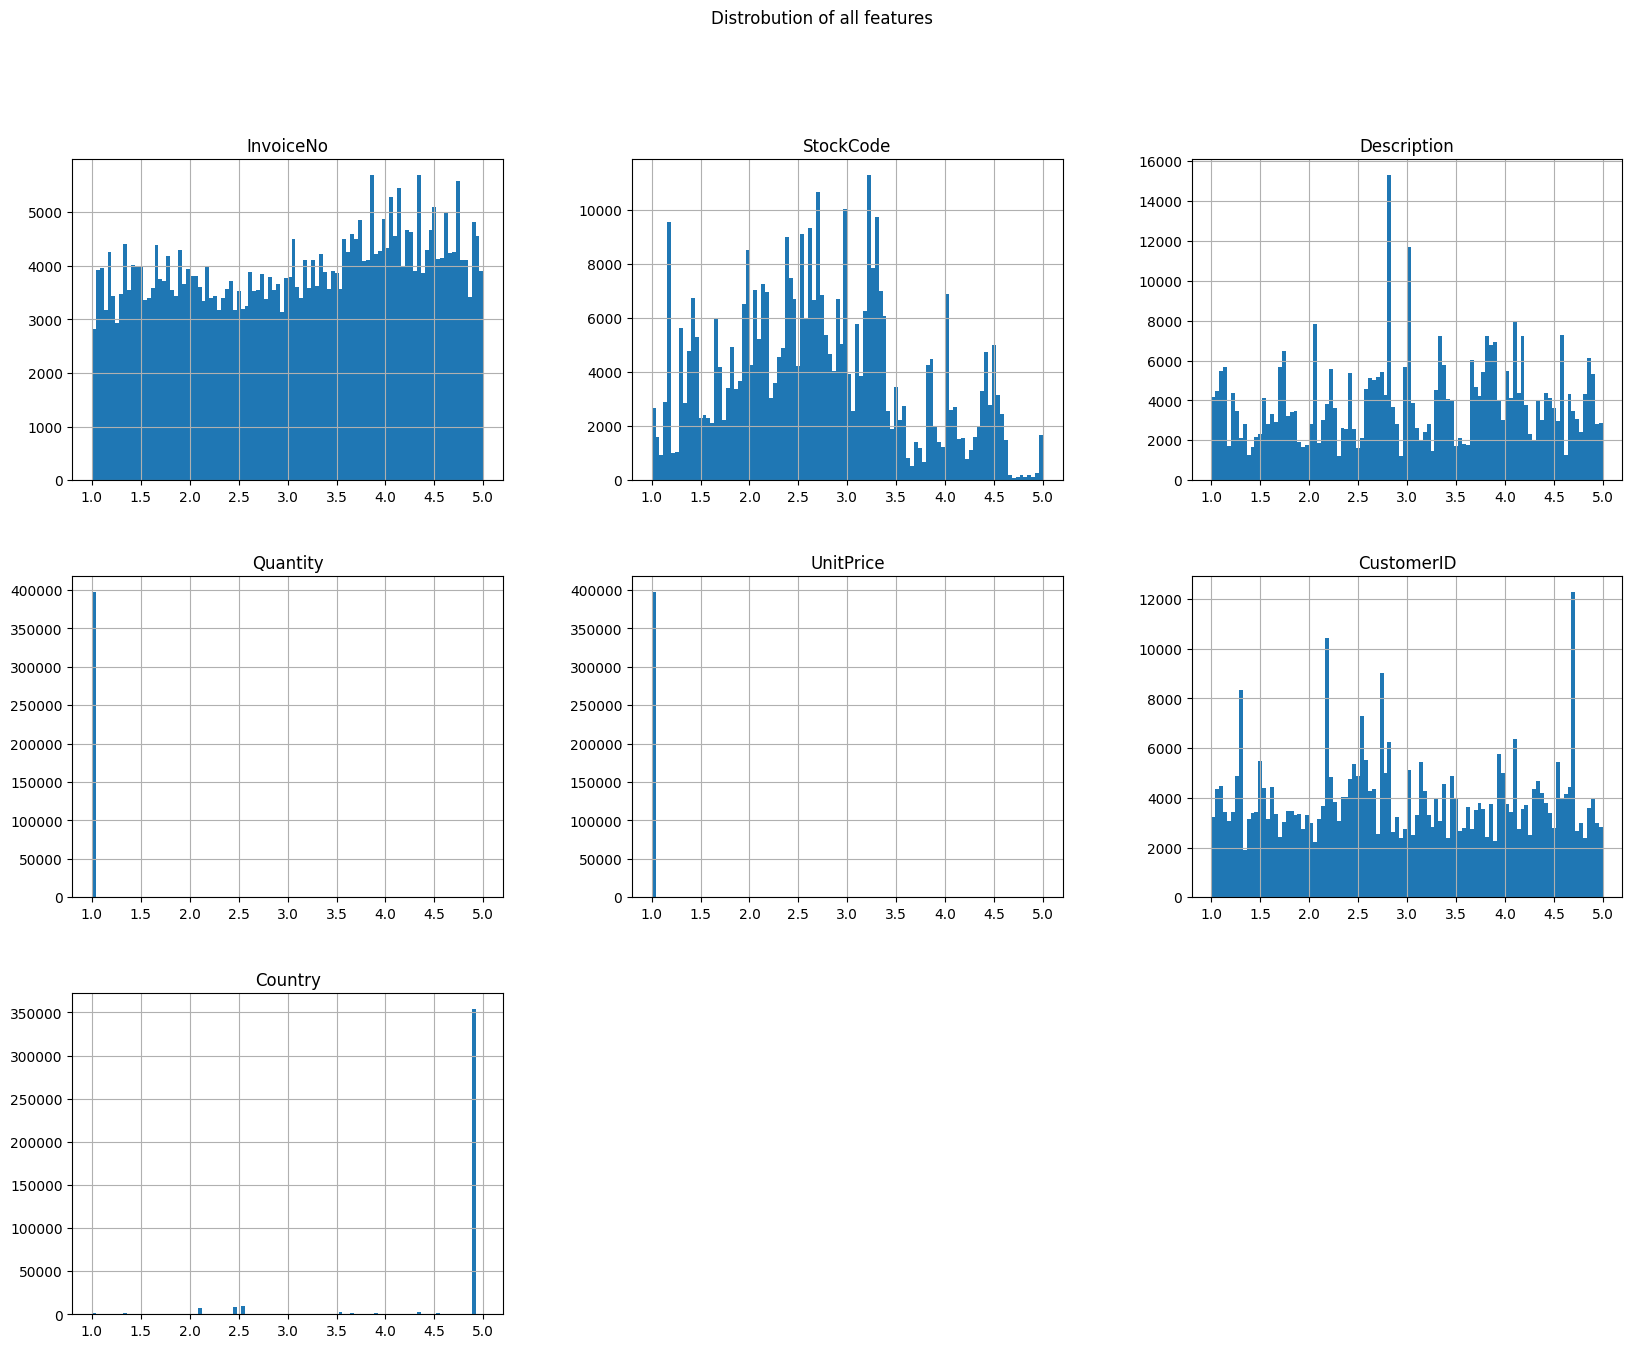

In [22]:
normalized_df.hist(bins=100,figsize=(20,15))
plt.suptitle('Distrobution of all features')
plt.show()

This cell generates histograms for all features in the `normalized_df` using `matplotlib.pyplot`. It creates a 4x2 grid of histograms, each with 100 bins, to visualize the distribution of each feature after normalization. The `plt.suptitle()` adds a main title to the entire figure.

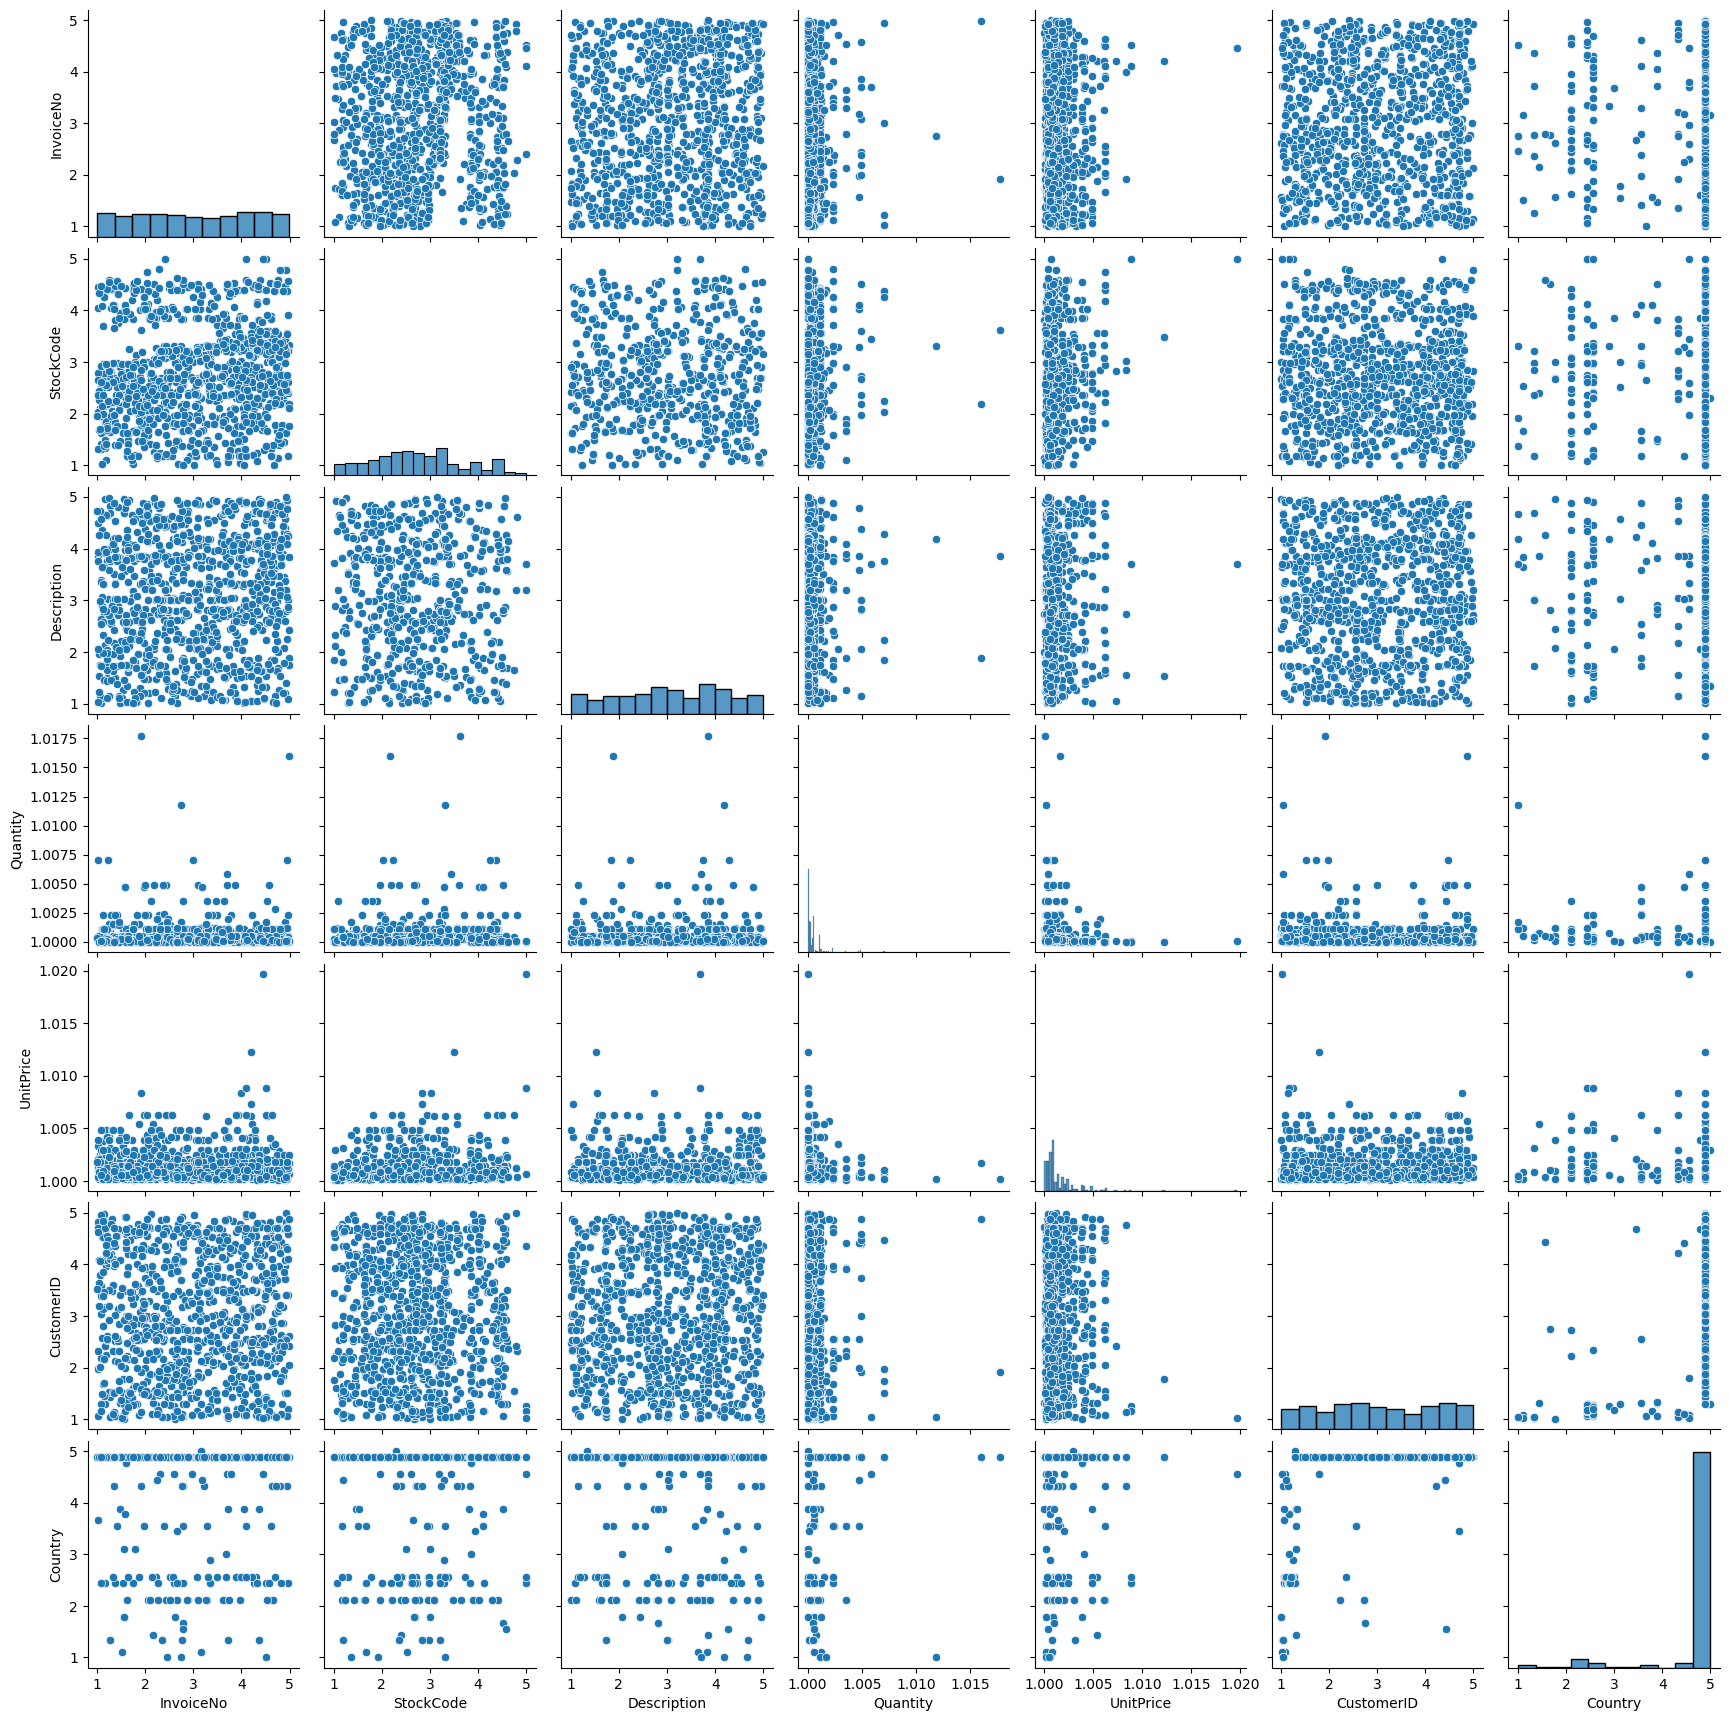

In [23]:
sns.pairplot(normalized_df.sample(1000))
plt.show()

This cell generates a pair plot for a sample of 1000 rows from `normalized_df` using `seaborn.pairplot`. A pair plot shows pairwise relationships between variables in a dataset, where each subplot is a scatter plot of two variables and histograms/KDEs are shown on the diagonals. Sampling is used to manage computational time for larger datasets.

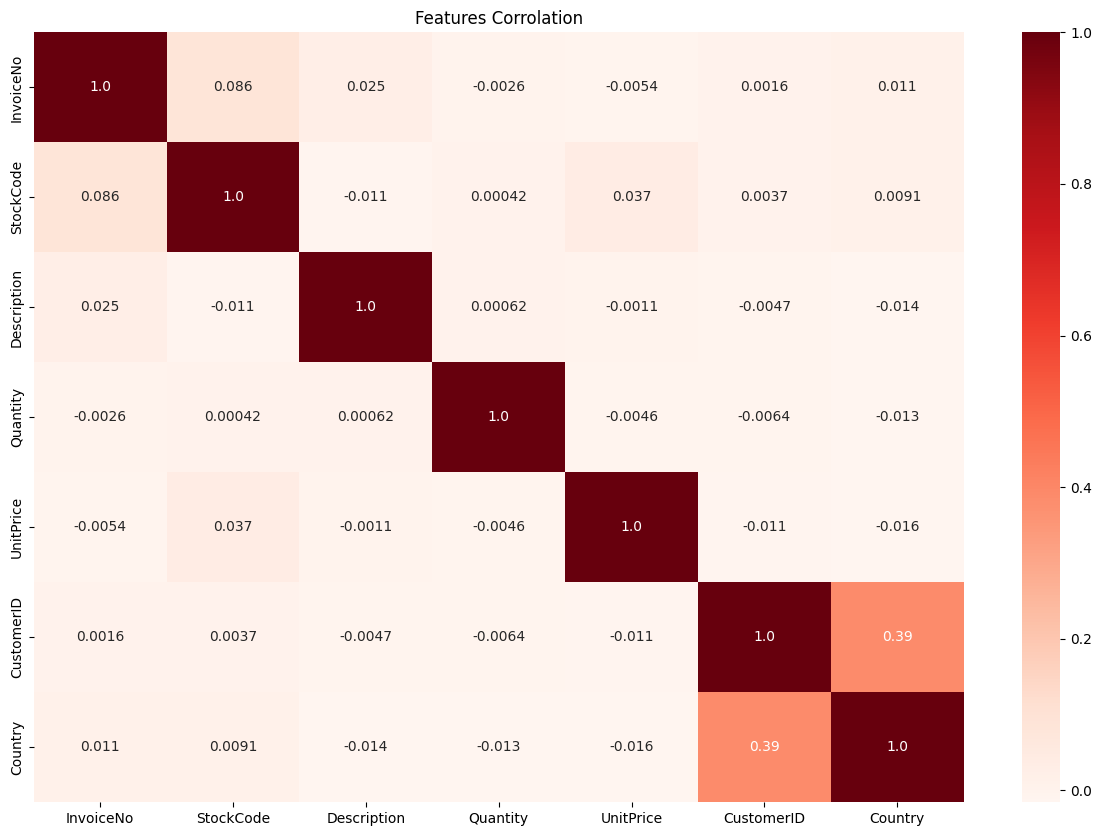

In [24]:
corr = normalized_df.corr()
plt.figure(figsize = (15,10))
sns.heatmap(corr,annot=True,cmap = plt.cm.Reds, fmt = '0.2')
plt.title('Features Corrolation')
plt.show()

This cell calculates and visualizes the correlation matrix of the `normalized_df`. It uses `pandas.DataFrame.corr()` to compute the pairwise correlation between features and then `seaborn.heatmap()` to create a heatmap. The `annot=True` argument displays the correlation values on the heatmap, and `cmap='Reds'` sets the color scheme, `fmt='0.2'` formats the annotations to two decimal places, making it easy to identify strong positive or negative correlations between features.

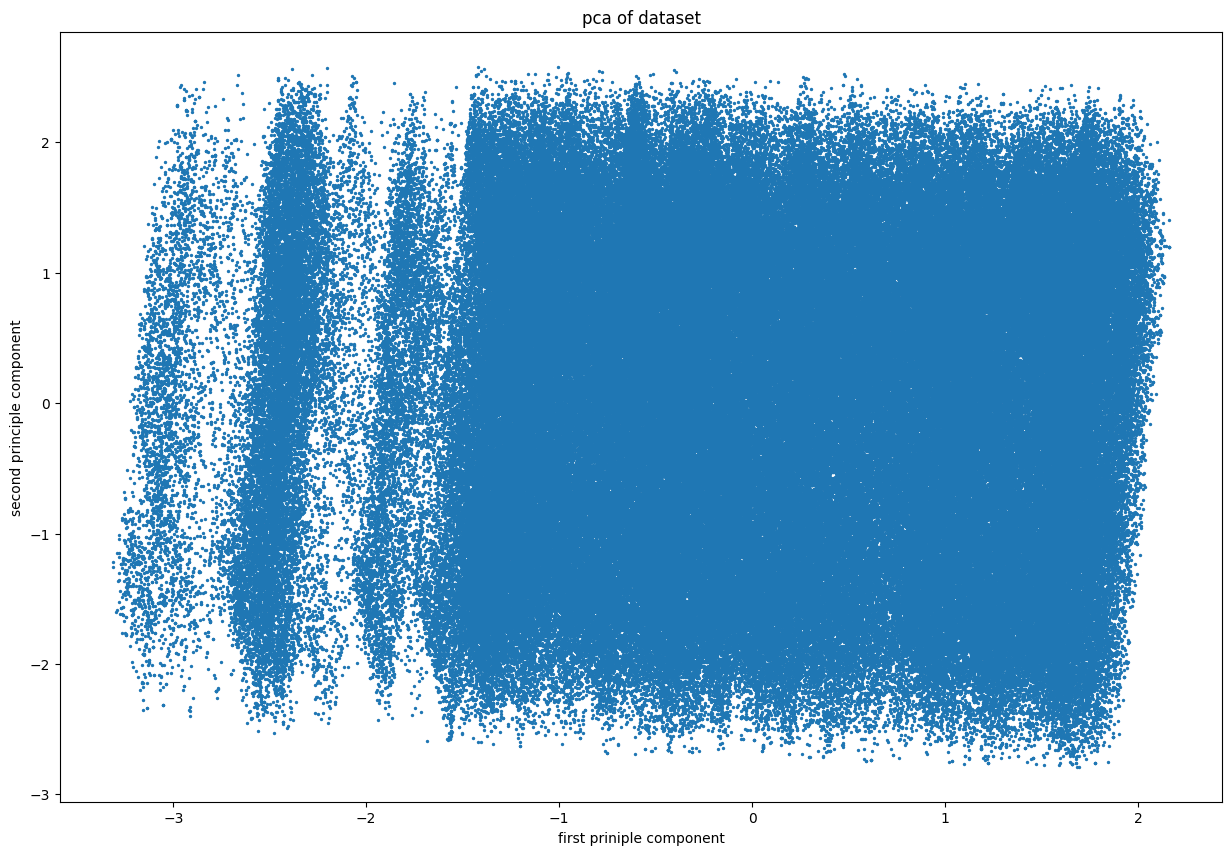

In [25]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(normalized_df)

plt.figure(figsize=(15,10))
plt.scatter(pca_result[:,0],pca_result[:,1],s = 2)
plt.title('pca of dataset')
plt.xlabel('first priniple component')
plt.ylabel('second principle component')
plt.show()

This cell performs Principal Component Analysis (PCA) to reduce the dimensionality of the `normalized_df` to 2 components. It then visualizes the data in this 2-dimensional space using a scatter plot. The plot helps to see if there are any natural clusters or patterns that emerge after dimensionality reduction.

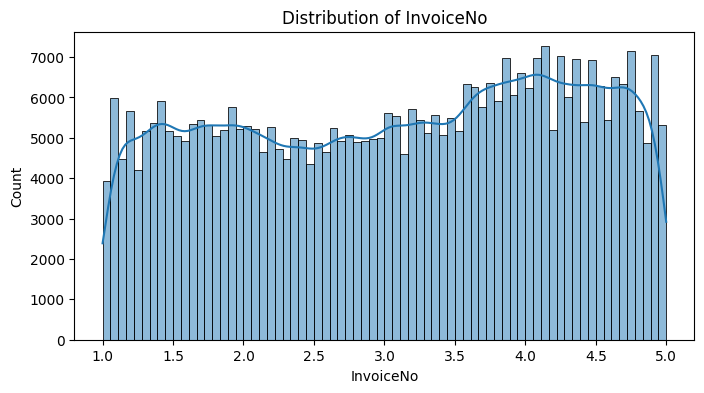

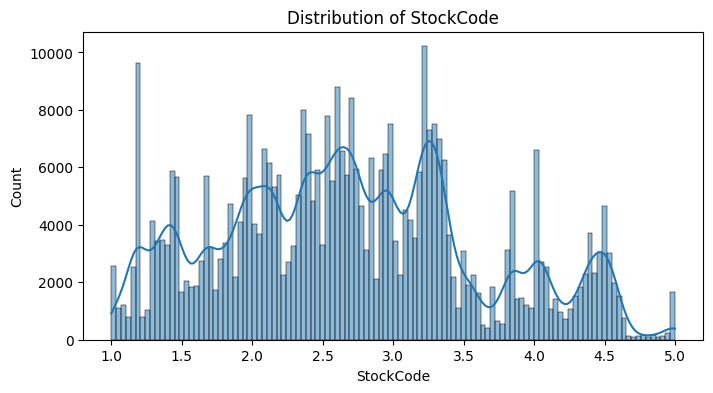

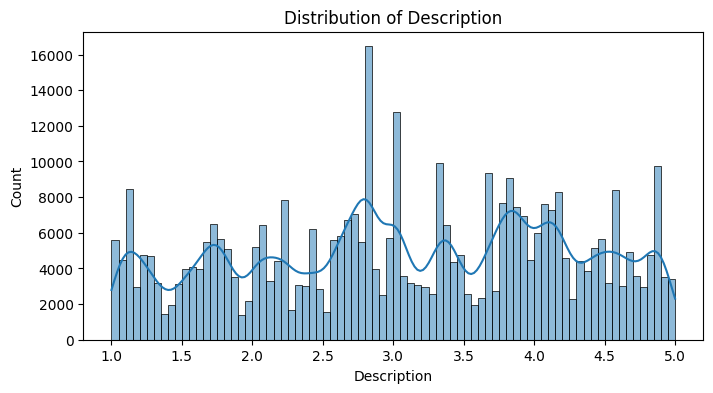

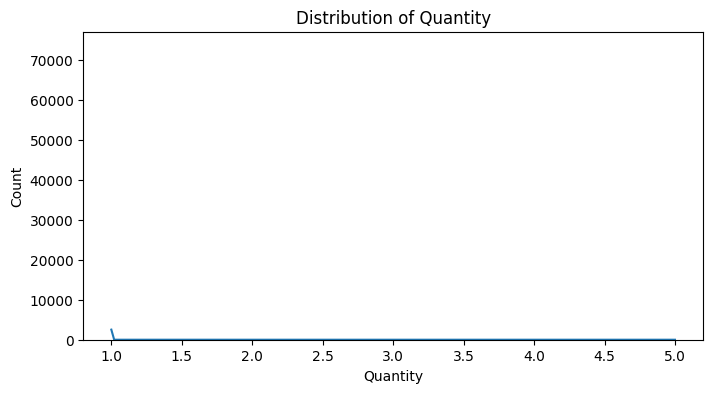

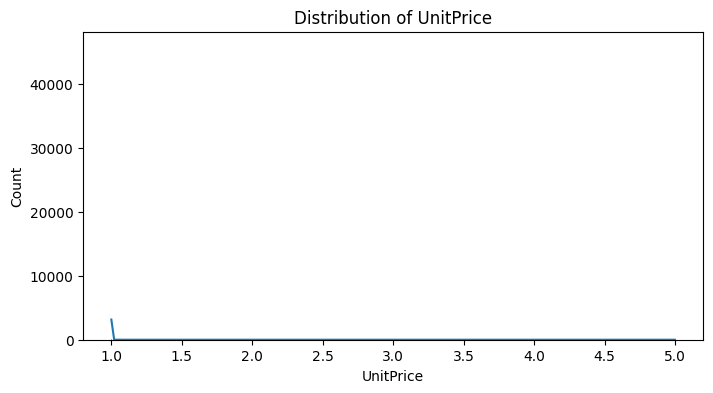

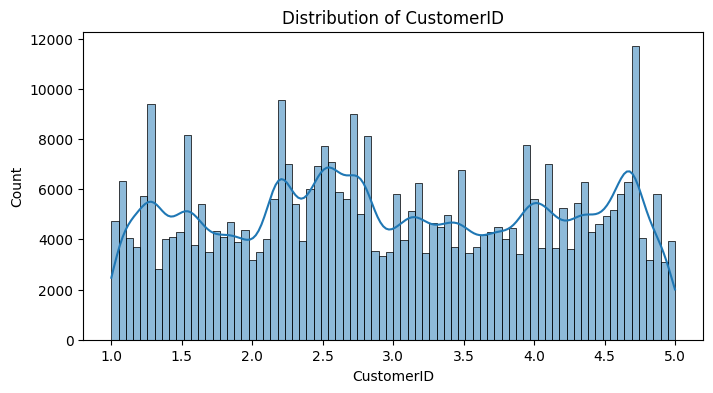

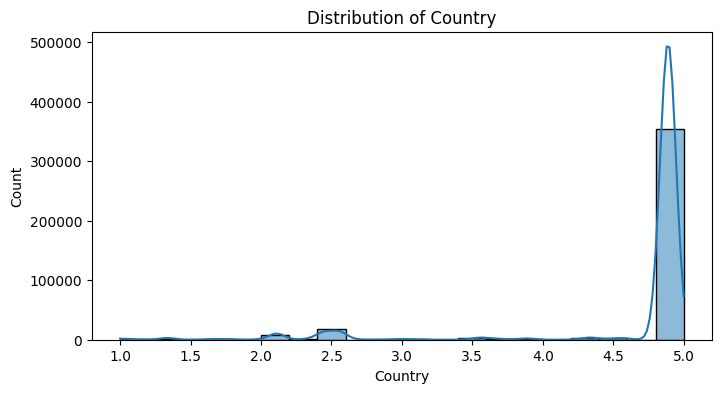

In [26]:
for col in normalized_df.columns:
    plt.figure(figsize=(8, 4))
    sns.histplot(normalized_df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

This cell iterates through each column of `normalized_df` and generates a histogram with a Kernel Density Estimate (KDE) plot for each feature using `seaborn.histplot`. This provides a detailed view of the distribution of individual features, showing both the frequency count and the estimated probability density.

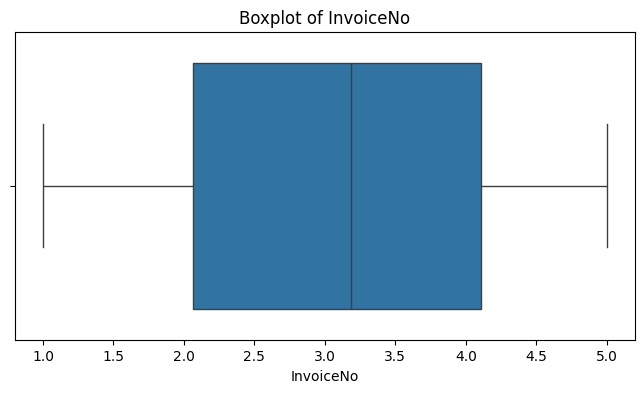

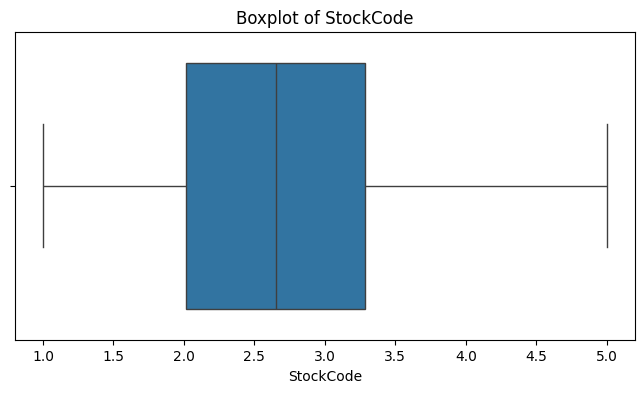

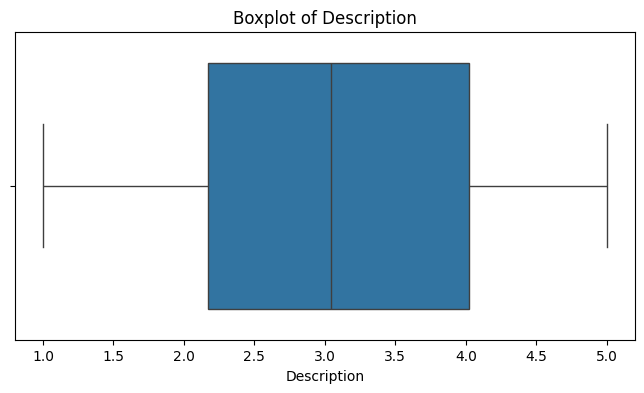

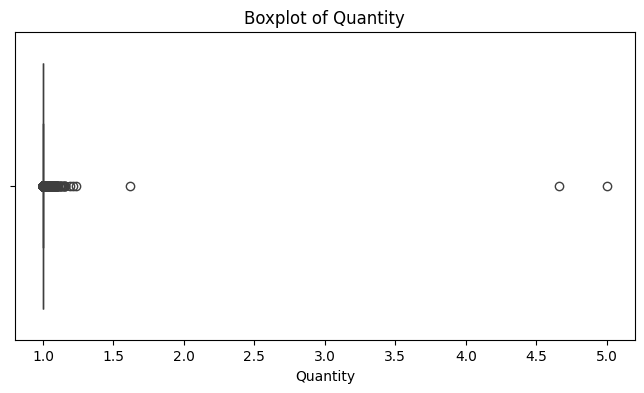

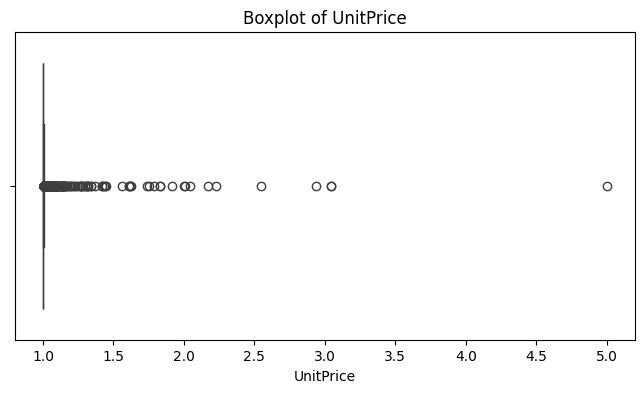

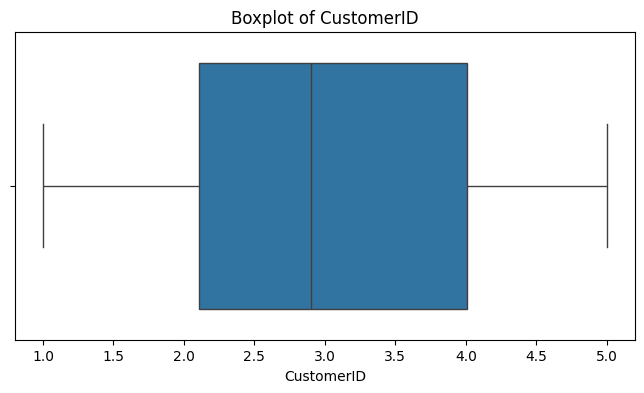

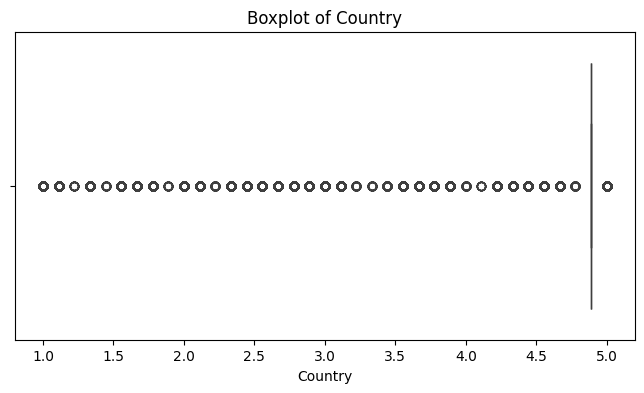

In [27]:
for col in normalized_df.columns:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=normalized_df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

This cell iterates through each column of `normalized_df` and generates a box plot for each feature using `seaborn.boxplot`. Box plots are useful for visualizing the distribution of numerical data and detecting outliers, showing the median, quartiles, and potential extreme values.

###Clustering and Evaluation

In [ ]:
wcss = []
si_score,ca_score,da_score = [],[],[]
k_value = [i for i in range (2,12)]

for k in range(2,12):

    km = KMeans(n_clusters=k, random_state=0)
    km.fit(normalized_df)
    labels = km.predict(normalized_df)

    #evaluation process

    si_score.append(silhouette_score(normalized_df,labels,sample_size=30000))
    ca_score.append(calinski_harabasz_score(normalized_df,labels))
    da_score.append(davies_bouldin_score(normalized_df,labels))
    wcss.append(km.inertia_)


    # ploting process
    plt.figure(figsize=(15,10))
plt.plot(range(2,12),wcss,marker = 'o')
plt.xlabel('number of the clusters')
plt.ylabel('wcss')
plt.title('Elbow method')
plt.grid()
plt.show()


plt.figure(figsize=(15,10))
bar_width = 0.2
index = np.arange(len(k_value))
plt.bar(index,si_score ,bar_width,label = 'silhouette_score',color = 'blue',alpha = 0.7)
plt.bar(index + bar_width ,np.log10(ca_score),bar_width,label = 'calinski_harabasz',color = 'red',alpha = 0.7)
plt.bar(index + 2*bar_width ,da_score,bar_width,label = 'davies_bouldin',color = 'yellow',alpha = 0.7)

plt.xlabel('K value')
plt.ylabel('Log10(Error score)')
plt.title('Clustering Evaluation Scores (Log Scale)')
plt.xticks(index+bar_width,k_value)
plt.legend()
plt.tight_layout()
plt.show()

error_dic = {'k_value':k_value,
             'silhouette_score':si_score,
             'calinski_harabasz':ca_score,
             'davies_bouldin':da_score}

error_df = pd.DataFrame(error_dic)
error_df

This cell performs K-Means clustering for a range of `k` values (2 to 11) to determine the optimal number of clusters. For each `k`, it fits the K-Means model, predicts cluster labels, and then calculates several evaluation metrics: Silhouette Score, Calinski-Harabasz Score, and Davies-Bouldin Score. It also calculates the Within-Cluster Sum of Squares (WCSS) for the Elbow Method. Finally, it plots the WCSS (Elbow Method) and the other evaluation scores to help in selecting the best `k`.

In [31]:
km = KMeans(n_clusters=5,random_state=0)
km.fit(normalized_df)
labels = km.predict(normalized_df)

This cell applies K-Means clustering with 5 clusters (chosen based on previous evaluation). It fits the model to the `normalized_df` and then predicts the cluster labels for each data point. These labels are then used in subsequent cells for analysis and visualization.

/tmp/ipykernel_3002/1543746537.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


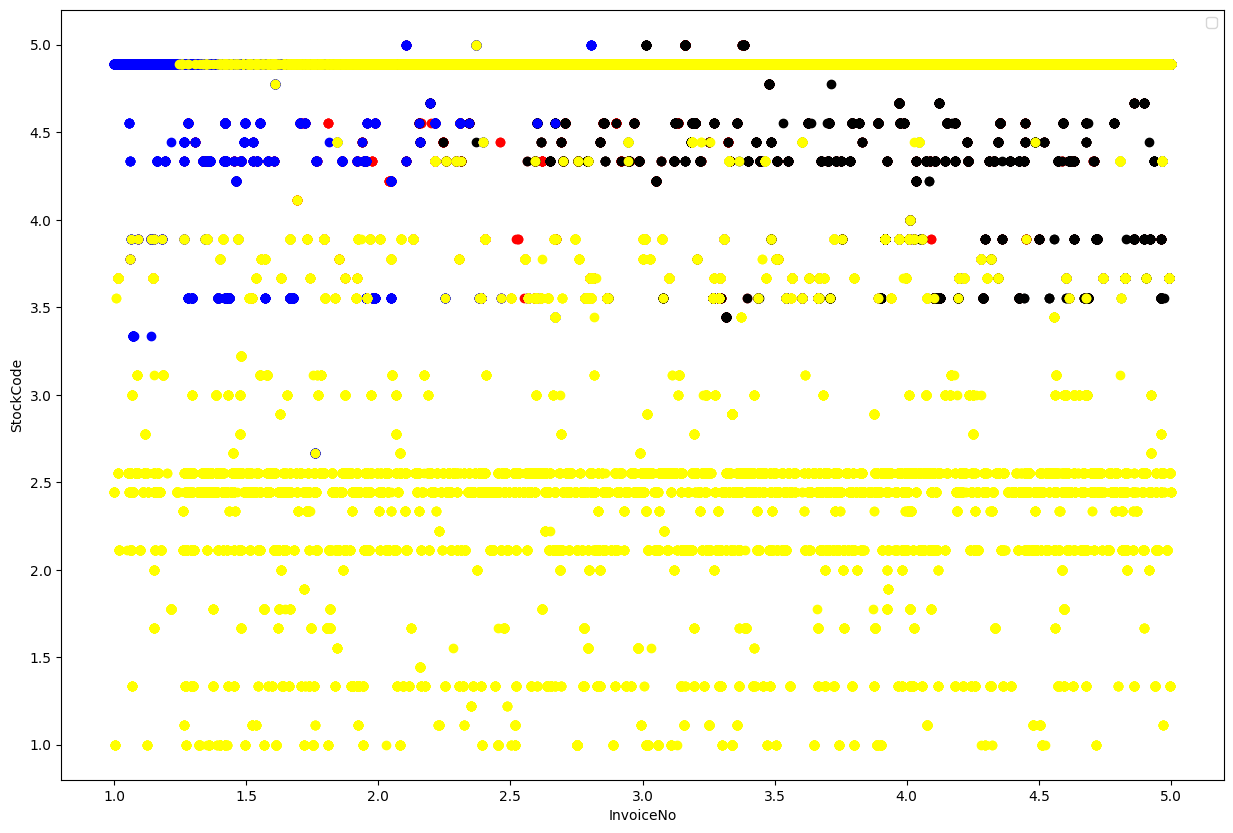

In [32]:
normalized_df['K-mean-cluster'] = labels
df_1 = normalized_df[normalized_df['K-mean-cluster'] == 0]
df_2 = normalized_df[normalized_df['K-mean-cluster'] == 1]
df_3 = normalized_df[normalized_df['K-mean-cluster'] == 2]
df_4 = normalized_df[normalized_df['K-mean-cluster'] == 3]
df_5 = normalized_df[normalized_df['K-mean-cluster'] == 4]

plt.figure(figsize=(15,10))
plt.scatter(df_1.InvoiceNo,df_1.Country,color = 'red')
plt.scatter(df_2.InvoiceNo,df_2.Country,color = 'black')
plt.scatter(df_3.InvoiceNo,df_3.Country,color = 'blue')
plt.scatter(df_4.InvoiceNo,df_4.Country,color = 'yellow')
plt.scatter(df_5.InvoiceNo,df_5.Country,color = 'yellow')


plt.xlabel('InvoiceNo')
plt.ylabel('StockCode')
plt.legend()

This cell adds the K-Means cluster labels as a new column named `'K-mean-cluster'` to the `normalized_df`. It then creates separate DataFrames (`df_1` through `df_5`) for each of the 5 clusters. Finally, it generates a scatter plot to visualize the clusters using 'InvoiceNo' and 'Country' as axes, with different colors for each cluster, although the chosen axes may not provide clear separation visually.

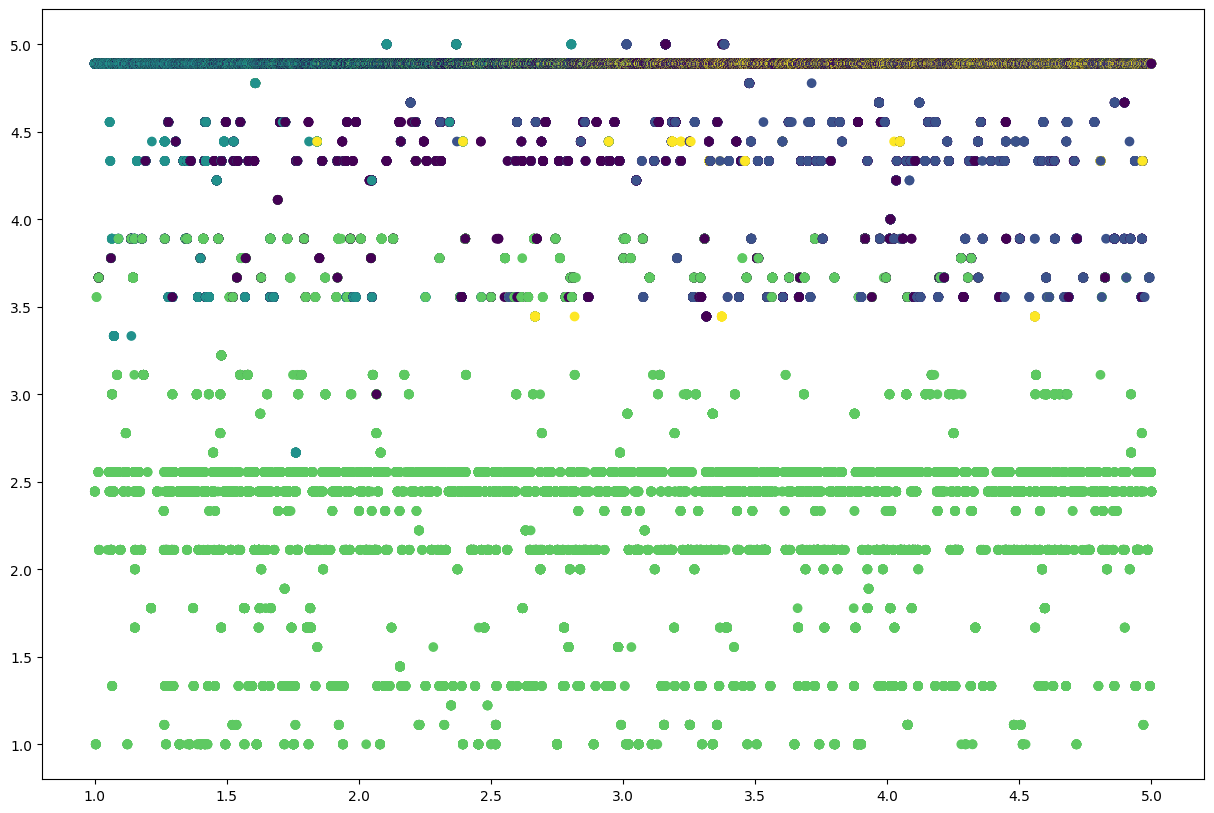

In [ ]:
plt.figure(figsize=(15,10))
plt.scatter(normalized_df.InvoiceNo,normalized_df.Country,c = normalized_df['K-mean-cluster'])

This cell creates another scatter plot to visualize the K-Means clusters, using 'InvoiceNo' and 'Country' from the `normalized_df`, and coloring the points based on the 'K-mean-cluster' column. This provides a direct visualization of how the data points are grouped into the 5 clusters according to these two features.

In [35]:
for i in range(2,6) :

    pca = PCA(n_components=i,random_state=0)
    pca_result = pca.fit_transform(normalized_df)
    explained_variance = pca.explained_variance_ratio_
    print(f'{i} component cover {np.sum(explained_variance)}')

2 component cover 0.5311699053654401
3 component cover 0.7020013516329298
4 component cover 0.8539466141153937
5 component cover 0.9657108561062469


This cell performs PCA with varying numbers of components (from 2 to 5) to assess the explained variance. For each number of components `i`, it fits PCA to the `normalized_df`, transforms the data, and then prints the cumulative explained variance ratio. This helps in understanding how much of the total variance in the data is captured by the principal components, aiding in selecting an appropriate number of components for dimensionality reduction.

the explained variance result : [0.34274224 0.18842766 0.17083145 0.15194526]


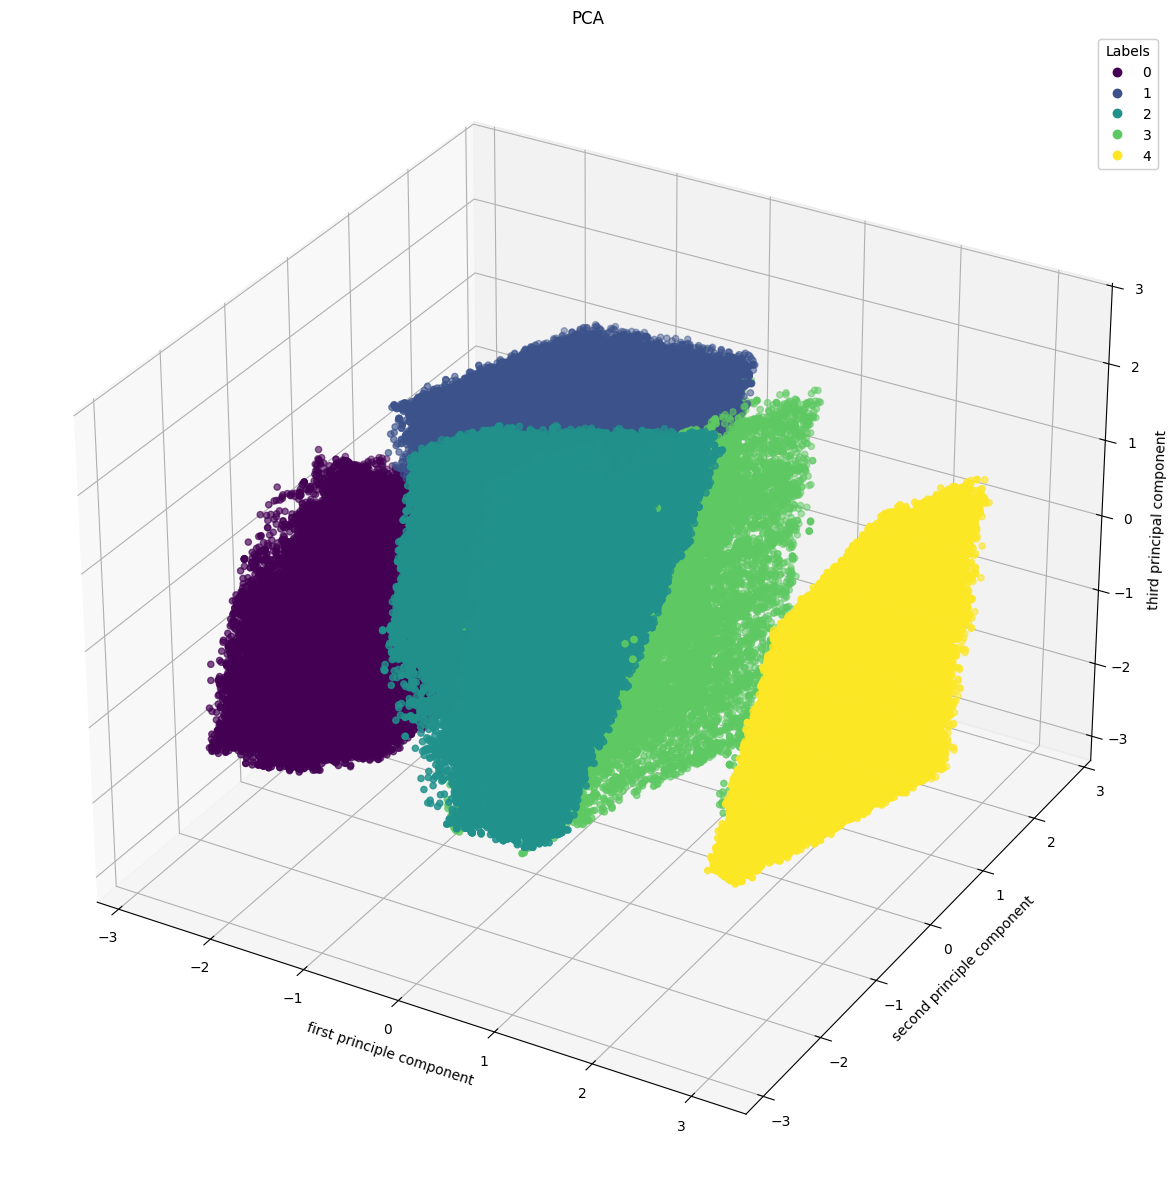

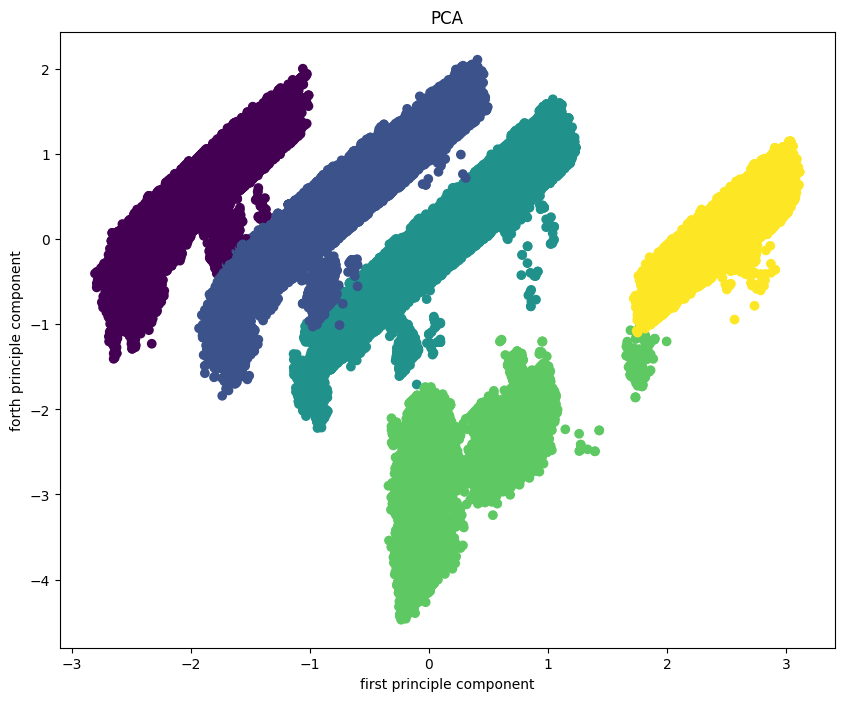

In [36]:
pca = PCA(n_components=4,random_state=0)
pca_result = pca.fit_transform(normalized_df)
print(f'the explained variance result : {pca.explained_variance_ratio_}')

plt.figure(figsize=(25,15))
ax = plt.axes(projection = '3d')

scatter = ax.scatter3D(pca_result[:,0],pca_result[:,1],pca_result[:,2],c=labels)
plt.xlabel('first principle component')
plt.ylabel('second principle component')
ax.set_zlabel('third principal component')
plt.title('PCA')
legend1 = ax.legend(*scatter.legend_elements(), title="Labels")
ax.add_artist(legend1)
plt.show()

plt.figure(figsize=(10,8))
plt.scatter(pca_result[:,0],pca_result[:,3],c=labels)
plt.xlabel('first principle component')
plt.ylabel('forth principle component')
plt.title('PCA')
plt.show()

This cell performs PCA with 4 components, based on the previous analysis of explained variance. It then visualizes the 4-component PCA results in two plots: a 3D scatter plot using the first three principal components, colored by the K-Means cluster labels, and a 2D scatter plot using the first and fourth principal components, also colored by the K-Means labels. These visualizations help to explore the cluster separation in reduced-dimensional space.

###Mean Shift Clustering and Visualization

In [42]:
sample_data = normalized_df.sample(5000)
sample_data.reset_index(drop=True,inplace=True)
sample_data

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID,Country,K-mean-cluster
0,3.646884,3.255770,4.194865,1.000148,1.002432,3.131320,4.888889,1
1,3.278284,1.922074,3.331194,1.000543,1.000418,3.131320,4.888889,1
2,2.939682,1.342112,3.904236,1.000000,1.000467,3.022420,4.888889,2
3,2.454545,3.215585,2.999487,1.000444,1.000811,1.259895,2.444444,3
4,4.430483,1.930763,4.875738,1.000099,1.001208,2.189659,4.888889,1
...,...,...,...,...,...,...,...,...
4995,1.222930,2.513983,3.025160,1.000049,1.000206,1.377946,4.888889,2
4996,4.045913,2.555254,4.445443,1.000543,1.000418,2.418440,4.888889,1
4997,2.475047,3.203638,2.586650,1.000346,1.001105,3.781972,4.888889,2
4998,4.362935,1.055390,4.917843,1.001185,1.000206,2.379089,4.888889,1


This cell prepares data for Mean Shift clustering. It takes a sample of 5000 data points from `normalized_df` and resets its index. This sampling is done to reduce computational time, as Mean Shift can be computationally intensive on large datasets. The sampled data is then displayed.

In [43]:
bandwith = estimate_bandwidth(sample_data,quantile=0.2,random_state=0)
bandwith

np.float64(2.6913043973707955)

This cell estimates the bandwidth for the Mean Shift algorithm using `estimate_bandwidth` from `sklearn.cluster`. The `quantile` parameter is set to 0.2, which influences the size of the kernel used for density estimation. The calculated bandwidth is crucial for the Mean Shift algorithm's performance and is printed.

In [44]:
ms = MeanShift(bandwidth=2.5)
ms.fit(sample_data)
ms_label = ms.labels_
ms_center = ms.cluster_centers_
np.unique(ms_label)

array([0, 1, 2])

This cell applies the Mean Shift clustering algorithm to the `sample_data` using a fixed bandwidth of 2.5 (though the previously estimated bandwidth was 2.69). It fits the model and then extracts the cluster labels (`ms_label`) and cluster centers (`ms_center`). Finally, it displays the unique cluster labels found by the algorithm.

In [45]:
sample_data['Mean-shift-cluster'] = ms_label
sample_data

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID,Country,K-mean-cluster,Mean-shift-cluster
0,3.646884,3.255770,4.194865,1.000148,1.002432,3.131320,4.888889,1,0
1,3.278284,1.922074,3.331194,1.000543,1.000418,3.131320,4.888889,1,0
2,2.939682,1.342112,3.904236,1.000000,1.000467,3.022420,4.888889,2,0
3,2.454545,3.215585,2.999487,1.000444,1.000811,1.259895,2.444444,3,2
4,4.430483,1.930763,4.875738,1.000099,1.001208,2.189659,4.888889,1,0
...,...,...,...,...,...,...,...,...,...
4995,1.222930,2.513983,3.025160,1.000049,1.000206,1.377946,4.888889,2,0
4996,4.045913,2.555254,4.445443,1.000543,1.000418,2.418440,4.888889,1,0
4997,2.475047,3.203638,2.586650,1.000346,1.001105,3.781972,4.888889,2,0
4998,4.362935,1.055390,4.917843,1.001185,1.000206,2.379089,4.888889,1,0


This cell adds the Mean Shift cluster labels as a new column named `'Mean-shift-cluster'` to the `sample_data` DataFrame. This allows for further analysis and visualization of the clusters identified by the Mean Shift algorithm. The updated `sample_data` DataFrame is then displayed.

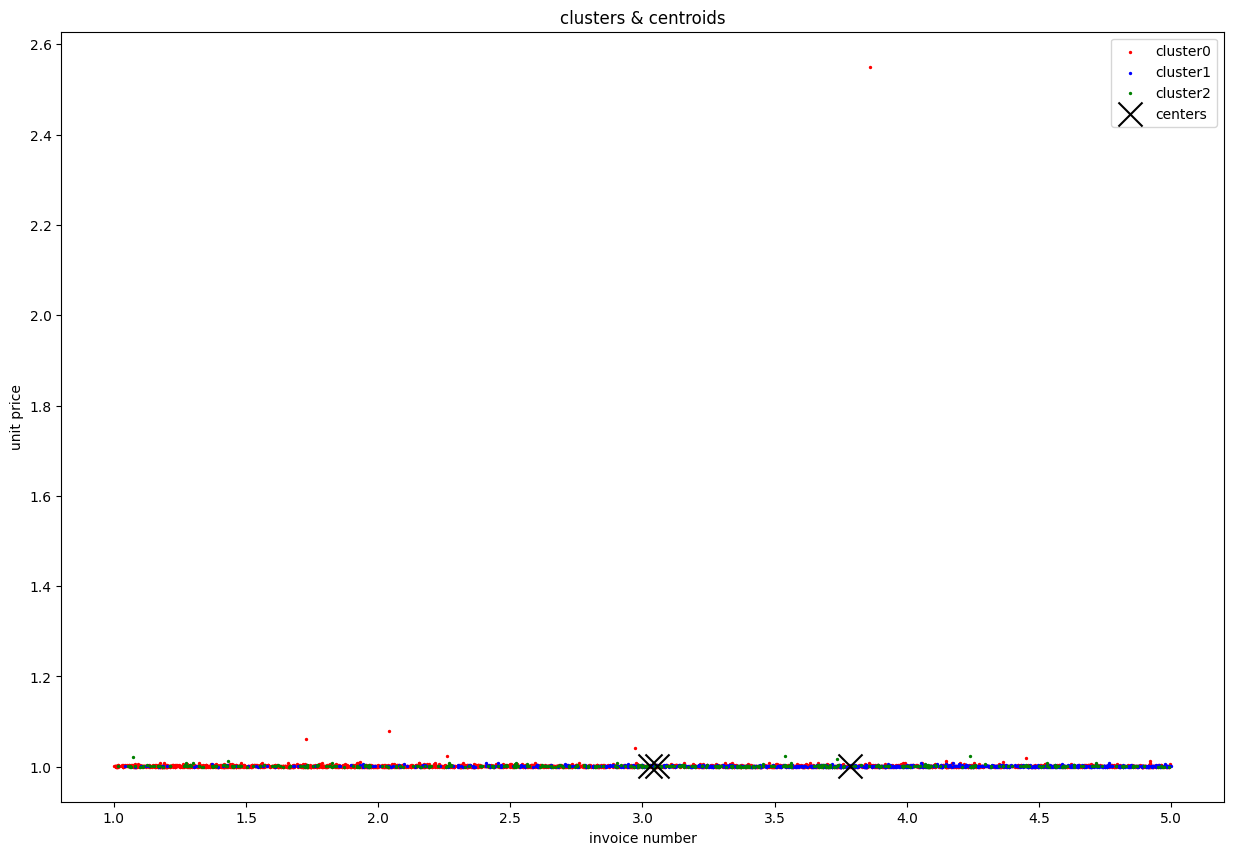

In [46]:
plt.figure(figsize=(15,10))
unique_clusters = np.unique(ms_label)
color_dic = {0:'red',1:'blue',2:'green'}
for i in unique_clusters :
    df = sample_data[sample_data['Mean-shift-cluster'] == i]
    labels = df['Mean-shift-cluster']
    plt.scatter(df.iloc[:,0],df.iloc[:,4],color = color_dic[i],label = f'cluster{i}',s = 2)


plt.scatter(ms_center[:,0],ms_center[:,4],color = 'black', s = 300, marker = 'x',label = 'centers')
plt.xlabel('invoice number')
plt.ylabel('unit price')
plt.title('clusters & centroids')
plt.legend()
plt.show()


This cell visualizes the Mean Shift clusters and their centroids. It iterates through the unique cluster labels identified by Mean Shift and plots the data points for each cluster in a different color, using 'invoice number' and 'unit price' as axes. The cluster centroids are marked with black 'x' symbols. This plot helps in understanding the distribution and separation of the clusters found by Mean Shift.